# Phase 2a: Vanilla GAN — BraTS 2025

Baseline adversarial framework. **U-Net-lite generator + PatchGAN discriminator.**

- Input: 128×128 single-channel MRI slices (T1c modality)
- Depthwise separable convolutions (~10× fewer params)
- Progressive training: 32→64→128
- Loss: Binary cross-entropy

In [1]:
import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Dataset — loads processed slices from Phase 1
# ══════════════════════════════════════════════════════════════════════════

PROC_DIR =  r"C:\Users\Admin\processed_data"# where Phase 1 saved the processed .npy files
MODALITY_IDX = 1  # 0=T1, 1=T1c, 2=T2, 3=FLAIR (T1c best for tumors

class BraTSDataset(Dataset):
    """Loads (4,128,128) slices, returns single modality + mask."""
    def __init__(self, split="train", modality=1):
        self.slice_dir = Path(PROC_DIR) / split / "slices"
        self.mask_dir  = Path(PROC_DIR) / split / "masks"
        self.files = sorted(self.slice_dir.glob("*.npy"))
        self.mod = modality
        print(f"  {split}: {len(self.files)} slices")
    
    def __len__(self): return len(self.files)
    
    def __getitem__(self, idx):
        f = self.files[idx]
        img = np.load(str(f)).astype(np.float32)           # (4,128,128)
        msk = np.load(str(self.mask_dir / f.name)).astype(np.float32)  # (4,128,128)
        
        # Single modality → (1,128,128)
        img_t = torch.from_numpy(img[self.mod:self.mod+1])
        msk_t = torch.from_numpy(msk)  # keep all 4 mask channels (4,128,128)
        return img_t, msk_t

train_ds = BraTSDataset("train", modality=MODALITY_IDX)
val_ds   = BraTSDataset("val",   modality=MODALITY_IDX)

BATCH_SIZE = 128
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

  train: 8382 slices
  val: 1662 slices


In [3]:
# ══════════════════ Shared Building Blocks ══════════════════

class DepthwiseSeparableConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, k, s, p, groups=in_ch, bias=bias)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=bias)
    def forward(self, x): return self.pw(self.dw(x))

class DSConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, act="leaky_relu", bn=True):
        super().__init__()
        layers = [DepthwiseSeparableConv2d(in_ch, out_ch, k, s, k//2)]
        if bn: layers.append(nn.BatchNorm2d(out_ch))
        acts = {"relu":nn.ReLU(True),"leaky_relu":nn.LeakyReLU(0.2,True),"none":nn.Identity()}
        layers.append(acts.get(act, nn.LeakyReLU(0.2,True)))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

def bce_loss(pred, real):
    t = torch.ones_like(pred) if real else torch.zeros_like(pred)
    return F.binary_cross_entropy_with_logits(pred, t)

class ProgressiveScheduler:
    def __init__(self, base_lr=2e-4):
        self.stages = [{"res":32,"ep":70,"lr_s":1.0},{"res":64,"ep":38,"lr_s":0.5},{"res":128,"ep":90,"lr_s":0.25}]
        self.base_lr = base_lr; self.idx = 0
    @property
    def res(self): return self.stages[self.idx]["res"]
    @property
    def epochs(self): return self.stages[self.idx]["ep"]
    @property
    def lr(self): return self.base_lr * self.stages[self.idx]["lr_s"]
    @property
    def n_stages(self): return len(self.stages)
    def advance(self): 
        if self.idx < len(self.stages)-1: self.idx+=1; return True
        return False
    def resize(self, x):
        r = self.res
        return F.interpolate(x, size=(r,r), mode="bilinear", align_corners=False) if x.shape[-1]!=r else x
    def set_lr(self, *opts):
        for o in opts:
            for pg in o.param_groups: pg["lr"]=self.lr
    def __repr__(self): return f"Stage {self.idx+1}/{len(self.stages)} res={self.res} lr={self.lr:.2e}"

print("✓ Building blocks ready.")

✓ Building blocks ready.


In [4]:
# ══════════════════ Vanilla GAN Generator ══════════════════

class VanillaGenerator(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, bf=32):
        super().__init__()
        self.enc1 = nn.Sequential(DSConvBlock(in_ch,bf), DSConvBlock(bf,bf), nn.MaxPool2d(2))
        self.enc2 = nn.Sequential(DSConvBlock(bf,bf*2), DSConvBlock(bf*2,bf*2), nn.MaxPool2d(2))
        self.enc3 = nn.Sequential(DSConvBlock(bf*2,bf*4), DSConvBlock(bf*4,bf*4), nn.MaxPool2d(2))
        self.enc4 = nn.Sequential(DSConvBlock(bf*4,bf*8), DSConvBlock(bf*8,bf*8), nn.MaxPool2d(2))
        self.bottleneck = nn.Sequential(DSConvBlock(bf*8,bf*8), DSConvBlock(bf*8,bf*8))
        self.up4=nn.ConvTranspose2d(bf*8,bf*4,2,stride=2); self.dec4=nn.Sequential(DSConvBlock(bf*8,bf*4),DSConvBlock(bf*4,bf*4))
        self.up3=nn.ConvTranspose2d(bf*4,bf*2,2,stride=2); self.dec3=nn.Sequential(DSConvBlock(bf*4,bf*2),DSConvBlock(bf*2,bf*2))
        self.up2=nn.ConvTranspose2d(bf*2,bf,2,stride=2);   self.dec2=nn.Sequential(DSConvBlock(bf*2,bf),DSConvBlock(bf,bf))
        self.up1=nn.ConvTranspose2d(bf,bf,2,stride=2);     self.dec1=nn.Sequential(DSConvBlock(bf+in_ch,bf),DSConvBlock(bf,bf))
        self.out_conv = nn.Sequential(nn.Conv2d(bf,out_ch,1), nn.Sigmoid())
    def forward(self, x):
        e1=self.enc1(x);e2=self.enc2(e1);e3=self.enc3(e2);e4=self.enc4(e3)
        b=self.bottleneck(e4)
        d4=self.dec4(torch.cat([self.up4(b),e3],1)); d3=self.dec3(torch.cat([self.up3(d4),e2],1))
        d2=self.dec2(torch.cat([self.up2(d3),e1],1)); d1=self.dec1(torch.cat([self.up1(d2),x],1))
        return self.out_conv(d1)

# ══════════════════ Vanilla PatchGAN Discriminator ══════════════════

class VanillaDiscriminator(nn.Module):
    def __init__(self, in_ch=1, bf=32):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch,bf,4,stride=2,padding=1), nn.LeakyReLU(0.2,True),
            DSConvBlock(bf,bf*2,k=4,s=2), DSConvBlock(bf*2,bf*4,k=4,s=2),
            DSConvBlock(bf*4,bf*4,k=4,s=1), nn.Conv2d(bf*4,1,4,stride=1,padding=1),
        )
    def forward(self, x): return self.model(x)

G = VanillaGenerator(1,1,32).to(device)
D = VanillaDiscriminator(1,32).to(device)
print(f"G: {sum(p.numel() for p in G.parameters()):,} params")
print(f"D: {sum(p.numel() for p in D.parameters()):,} params")

G: 525,715 params
D: 33,441 params


In [5]:
# ══════════════════ Training Loop ══════════════════
SAVE_DIR = r"C:\Users\Admin\Downloads\code\Vanilla GAN"
os.makedirs(SAVE_DIR, exist_ok=True)

LR=2e-4
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))
sched = ProgressiveScheduler(base_lr=LR)

g_losses, d_losses = [], []
fixed_noise = torch.randn(5, 1, 32, 32, device=device)  # 5 fixed noise vectors

iteration_counter = 0

for stage in range(sched.n_stages):
    print(f"\n{'='*70}")
    print(f"  {sched}")
    print(f"{'='*70}\n")
    sched.set_lr(opt_G, opt_D)
    
    for epoch in range(sched.epochs):
        G.train(); D.train()
        epoch_g_loss = []
        epoch_d_loss = []
        
        for batch_idx, (real, masks) in enumerate(tqdm(train_dl, desc=f"Stage {stage+1}/{sched.n_stages} | Epoch {epoch+1}/{sched.epochs}", leave=False)):
            real = sched.resize(real.to(device))
            z = torch.randn_like(real)
            
            # Discriminator update
            fake = G(z).detach()
            lD = bce_loss(D(real),True) + bce_loss(D(fake),False)
            opt_D.zero_grad(); lD.backward(); opt_D.step()
            
            # Generator update
            fake = G(z)
            lG = bce_loss(D(fake),True)
            opt_G.zero_grad(); lG.backward(); opt_G.step()
            
            # Track batch losses
            epoch_g_loss.append(lG.item())
            epoch_d_loss.append(lD.item())
            
            iteration_counter += 1
        
        # ── Per-epoch: create folder, save 5 images + weights ──
        epoch_dir = os.path.join(SAVE_DIR, f"stage{stage+1:02d}_epoch{epoch+1:03d}")
        os.makedirs(epoch_dir, exist_ok=True)
        
        # Generate 5 sample images
        G.eval()
        with torch.no_grad():
            resized_noise = sched.resize(fixed_noise)
            generated = G(resized_noise).cpu().numpy()  # (5, 1, H, W)
        
        for i in range(5):
            fig, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax.imshow(generated[i, 0], cmap="gray")
            ax.axis("off")
            ax.set_title(f"S{stage+1} E{epoch+1} Sample {i+1}\nG:{np.mean(epoch_g_loss):.4f} D:{np.mean(epoch_d_loss):.4f}", fontsize=9)
            plt.tight_layout()
            plt.savefig(os.path.join(epoch_dir, f"sample_{i+1:02d}.png"), dpi=100, bbox_inches="tight")
            plt.close()
        
        # Save weights inside this epoch folder
        torch.save({
            "G": G.state_dict(),
            "D": D.state_dict(),
            "epoch": epoch + 1,
            "stage": stage + 1,
            "g_loss": np.mean(epoch_g_loss),
            "d_loss": np.mean(epoch_d_loss),
        }, os.path.join(epoch_dir, "weights.pt"))
        
        G.train()
        
        # Calculate mean losses for epoch
        mean_g_loss = np.mean(epoch_g_loss)
        mean_d_loss = np.mean(epoch_d_loss)
        
        g_losses.append(mean_g_loss)
        d_losses.append(mean_d_loss)
        
        print(f"  Epoch {epoch+1:3d}/{sched.epochs} | "
              f"G_Loss: {mean_g_loss:.6f} | "
              f"D_Loss: {mean_d_loss:.6f} | "
              f"Saved → {epoch_dir}")
    
    sched.advance()

torch.save(G.state_dict(), f"{SAVE_DIR}/generator_final.pt")
torch.save(D.state_dict(), f"{SAVE_DIR}/discriminator_final.pt")
print("\n" + "="*70)
print("✓ Vanilla GAN training complete!")
print(f"✓ Total iterations processed: {iteration_counter}")
print(f"✓ Per-epoch folders saved to: {SAVE_DIR}")
print("="*70)



  Stage 1/3 res=32 lr=2.00e-04



Stage 1/3 | Epoch 1/70:   0%|          | 0/66 [00:00<?, ?it/s]

  Epoch   1/70 | G_Loss: 0.985196 | D_Loss: 1.082812 | Saved → C:\Users\Admin\Downloads\code\Vanilla GAN\stage01_epoch001


Stage 1/3 | Epoch 2/70:   0%|          | 0/66 [00:00<?, ?it/s]

  Epoch   2/70 | G_Loss: 1.270415 | D_Loss: 0.840716 | Saved → C:\Users\Admin\Downloads\code\Vanilla GAN\stage01_epoch002


...

  Epoch  88/90 | G_Loss: 0.694576 | D_Loss: 1.386742 | Saved → C:\Users\Admin\Downloads\code\Vanilla GAN\stage03_epoch088


Stage 3/3 | Epoch 89/90:   0%|          | 0/66 [00:00<?, ?it/s]

  Epoch  89/90 | G_Loss: 0.692391 | D_Loss: 1.387006 | Saved → C:\Users\Admin\Downloads\code\Vanilla GAN\stage03_epoch089


Stage 3/3 | Epoch 90/90:   0%|          | 0/66 [00:00<?, ?it/s]

  Epoch  90/90 | G_Loss: 0.692734 | D_Loss: 1.386871 | Saved → C:\Users\Admin\Downloads\code\Vanilla GAN\stage03_epoch090

✓ Vanilla GAN training complete!
✓ Total iterations processed: 13068
✓ Per-epoch folders saved to: C:\Users\Admin\Downloads\code\Vanilla GAN



  TRAINING SUMMARY
Total Epochs Trained: 198
Total Iterations: 13068
Final Generator Loss:   0.692734
Final Discriminator Loss: 1.386871
Best Generator Loss:    0.680496 (Epoch 9)
Best Discriminator Loss: 0.761580 (Epoch 3)



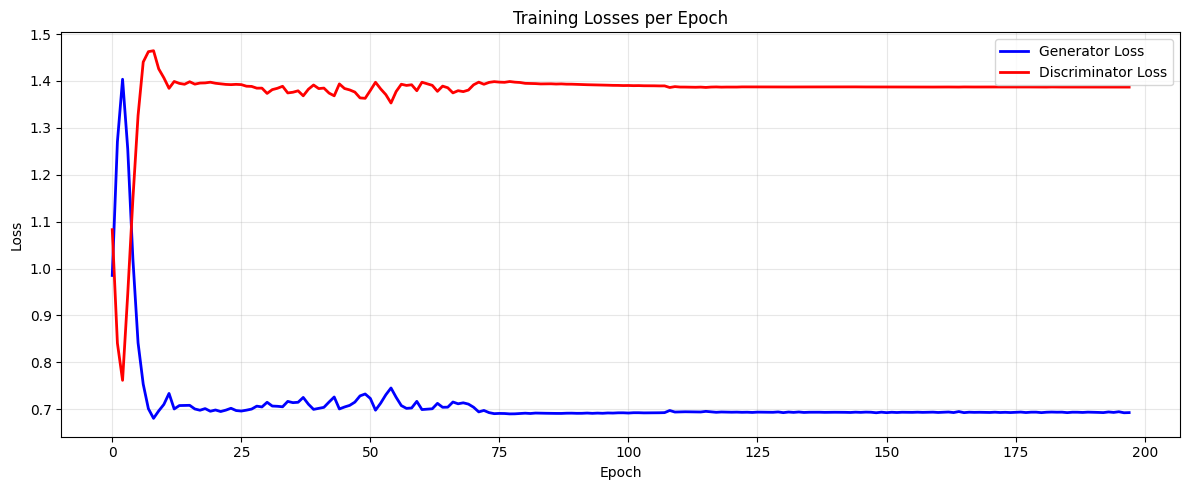

In [10]:
import matplotlib.pyplot as plt
import numpy as np


# ══════════════════ Visualization & Results ══════════════════
print("\n" + "="*70)
print("  TRAINING SUMMARY")
print("="*70)
print(f"Total Epochs Trained: {len(g_losses)}")
print(f"Total Iterations: {iteration_counter}")
print(f"Final Generator Loss:   {g_losses[-1]:.6f}")
print(f"Final Discriminator Loss: {d_losses[-1]:.6f}")
print(f"Best Generator Loss:    {min(g_losses):.6f} (Epoch {np.argmin(g_losses)+1})")
print(f"Best Discriminator Loss: {min(d_losses):.6f} (Epoch {np.argmin(d_losses)+1})")
print("="*70 + "\n")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(g_losses, label="Generator Loss", linewidth=2, color="blue")
ax.plot(d_losses, label="Discriminator Loss", linewidth=2, color="red")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Losses per Epoch")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/loss.png", dpi=150)
plt.show()

In [11]:
# ══════════════════ Testing / Evaluation ══════════════════
# Generate samples on the test split and compute a simple reconstruction metric (MSE)
TEST_OUT = os.path.join(SAVE_DIR, "test_outputs")
os.makedirs(TEST_OUT, exist_ok=True)

# Prepare test dataloader
test_ds = BraTSDataset("test", modality=MODALITY_IDX)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Try to (re)load the final generator weights if available
ckpt_path = os.path.join(SAVE_DIR, "generator_final.pt")
if os.path.exists(ckpt_path):
    try:
        state = torch.load(ckpt_path, map_location=device)
        # state may be a state_dict or a dict with key 'G'
        if isinstance(state, dict) and "G" in state and isinstance(state["G"], dict):
            G.load_state_dict(state["G"])
        else:
            G.load_state_dict(state)
        print(f"Loaded generator weights from: {ckpt_path}")
    except Exception as e:
        print("Warning: failed to load generator checkpoint:", e)
else:
    print("No generator checkpoint found, using current in-memory model.")

G.eval()

total_mse = 0.0
count = 0

for batch_idx, (real, masks) in enumerate(tqdm(test_dl, desc="Testing", leave=True)):
    real = sched.resize(real.to(device))
    # Generate with random z (Vanilla GAN is unconditional)
    z = torch.randn_like(real)
    with torch.no_grad():
        gen = G(z)
    # Compute batch MSE between generated images and real images (informational)
    batch_mse = F.mse_loss(gen, real, reduction="mean").item()
    total_mse += batch_mse * real.size(0)
    count += real.size(0)

    # Save per-sample images and numpy arrays for inspection
    gen_np = gen.cpu().numpy()
    real_np = real.cpu().numpy()
    for i in range(gen_np.shape[0]):
        out_png = os.path.join(TEST_OUT, f"batch{batch_idx+1:04d}_sample{i+1:03d}.png")
        out_npy = os.path.join(TEST_OUT, f"batch{batch_idx+1:04d}_sample{i+1:03d}.npy")
        plt.imsave(out_png, gen_np[i, 0], cmap="gray")
        np.save(out_npy, gen_np[i, 0])

avg_mse = total_mse / max(1, count)
print(f"\nTest set: {count} samples processed")
print(f"Average MSE (generated vs real): {avg_mse:.6f}")
print(f"Saved generated samples to: {TEST_OUT}")

  test: 1138 slices
Loaded generator weights from: C:\Users\Admin\Downloads\code\Vanilla GAN\generator_final.pt


Testing:   0%|          | 0/9 [00:00<?, ?it/s]


Test set: 1138 samples processed
Average MSE (generated vs real): 0.142937
Saved generated samples to: C:\Users\Admin\Downloads\code\Vanilla GAN\test_outputs


In [17]:
!pip install scikit-image

  Using cached scikit_image-0.25.2-cp310-cp310-win_amd64.whl.metadata (14 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2025.5.10-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.25.2-cp310-cp310-win_amd64.whl (12.8 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached tifffile-2025.5.10-py3-none-any.whl (226 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- -----

In [19]:
# ══════════════════ Testing / Evaluation ══════════════════
import os, numpy as np, torch, torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from scipy.spatial.distance import directed_hausdorff
from scipy.stats import entropy
from scipy.spatial.distance import cdist
from scipy.spatial.distance import directed_hausdorff, cdist

TEST_OUT = os.path.join(SAVE_DIR, "test_outputs")
os.makedirs(TEST_OUT, exist_ok=True)

# ── Test Dataloader ──
test_ds  = BraTSDataset("test", modality=MODALITY_IDX)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Load generator weights ──
ckpt_path = os.path.join(SAVE_DIR, "generator_final.pt")
if os.path.exists(ckpt_path):
    try:
        state = torch.load(ckpt_path, map_location=device)
        G.load_state_dict(state["G"] if (isinstance(state, dict) and "G" in state) else state)
        print(f"Loaded: {ckpt_path}")
    except Exception as e:
        print("Warning:", e)
else:
    print("No checkpoint found, using in-memory model.")

G.eval()

# ── Metric helpers ──
def roi_mse(gen, real, mask):
    """MSE only inside tumor ROI (any mask channel > 0)."""
    roi = (mask.sum(axis=0) > 0).astype(np.float32)  # (H,W)
    if roi.sum() == 0:
        return float("nan")
    diff = (gen - real) ** 2
    return float((diff * roi).sum() / roi.sum())

def roi_ssim(gen, real, mask):
    """SSIM only inside bounding box of ROI."""
    roi = (mask.sum(axis=0) > 0)
    if roi.sum() == 0:
        return float("nan")
    ys, xs = np.where(roi)
    y1,y2,x1,x2 = ys.min(),ys.max()+1,xs.min(),xs.max()+1
    patch_g = gen[y1:y2, x1:x2]
    patch_r = real[y1:y2, x1:x2]
    if patch_g.shape[0] < 7 or patch_g.shape[1] < 7:
        return float("nan")
    data_range = max(patch_r.max() - patch_r.min(), 1e-6)
    return float(ssim(patch_g, patch_r, data_range=data_range))

def hd95(gen_bin, real_bin):
    """Hausdorff Distance 95th percentile between two binary masks."""
    gp = np.argwhere(gen_bin > 0.5)
    rp = np.argwhere(real_bin > 0.5)
    if len(gp) == 0 or len(rp) == 0:
        return float("nan")
    d1 = directed_hausdorff(gp, rp)[0]
    d2 = directed_hausdorff(rp, gp)[0]
    # Use 95th percentile of all pairwise distances
    from scipy.spatial.distance import cdist
    dists = np.concatenate([cdist(gp, rp).min(axis=1),
                            cdist(rp, gp).min(axis=1)])
    return float(np.percentile(dists, 95))

def dsc(gen_bin, real_bin):
    """Dice Similarity Coefficient."""
    inter = ((gen_bin > 0.5) & (real_bin > 0.5)).sum()
    total = (gen_bin > 0.5).sum() + (real_bin > 0.5).sum()
    return float(2 * inter / total) if total > 0 else float("nan")

def kl_div(gen, real, bins=256):
    """KL Divergence between intensity histograms."""
    g_hist, _ = np.histogram(gen.flatten(), bins=bins, range=(0,1), density=True)
    r_hist, _ = np.histogram(real.flatten(), bins=bins, range=(0,1), density=True)
    g_hist = g_hist + 1e-10
    r_hist = r_hist + 1e-10
    g_hist /= g_hist.sum()
    r_hist /= r_hist.sum()
    return float(entropy(g_hist, r_hist))

# ── Evaluation loop ──
metrics = {"roi_mse": [], "roi_ssim": [], "hd95": [], "dsc": [], "kl_div": []}
count = 0

for batch_idx, (real, masks) in enumerate(tqdm(test_dl, desc="Testing", leave=True)):
    real_t  = real.to(device)
    masks_t = masks.to(device)
    z       = torch.randn_like(real_t)

    with torch.no_grad():
        gen_t = G(z)

    gen_np   = gen_t.cpu().numpy()    # (B,1,H,W)
    real_np  = real_t.cpu().numpy()
    masks_np = masks_t.cpu().numpy()  # (B,4,H,W)

    for i in range(gen_np.shape[0]):
        g  = gen_np[i, 0]    # (H,W)
        r  = real_np[i, 0]
        m  = masks_np[i]     # (4,H,W)

        # Binarize generated image at 0.5 for DSC/HD95
        g_bin = (g > 0.5).astype(np.float32)
        r_bin = (r > 0.5).astype(np.float32)

        metrics["roi_mse"].append(roi_mse(g, r, m))
        metrics["roi_ssim"].append(roi_ssim(g, r, m))
        metrics["hd95"].append(hd95(g_bin, r_bin))
        metrics["dsc"].append(dsc(g_bin, r_bin))
        metrics["kl_div"].append(kl_div(g, r))

        # Save outputs
        plt.imsave(os.path.join(TEST_OUT, f"batch{batch_idx+1:04d}_sample{i+1:03d}.png"), g, cmap="gray")
        np.save(os.path.join(TEST_OUT,    f"batch{batch_idx+1:04d}_sample{i+1:03d}.npy"), g)

        count += 1

# ── Summary ──
def safe_mean(lst):
    vals = [v for v in lst if not np.isnan(v)]
    return np.mean(vals) if vals else float("nan")

print(f"\n{'='*60}")
print(f"  EVALUATION SUMMARY — Vanilla GAN  ({count} samples)")
print(f"{'='*60}")
print(f"  ROI-MSE  (↓ better) : {safe_mean(metrics['roi_mse']):.6f}")
print(f"  ROI-SSIM (↑ better) : {safe_mean(metrics['roi_ssim']):.6f}")
print(f"  HD95     (↓ better) : {safe_mean(metrics['hd95']):.4f} px")
print(f"  DSC      (↑ better) : {safe_mean(metrics['dsc']):.6f}")
print(f"  KL-Div   (↓ better) : {safe_mean(metrics['kl_div']):.6f}")
print(f"{'='*60}")

# Save metrics to file
np.save(os.path.join(TEST_OUT, "metrics.npy"), metrics)
print(f"✓ Metrics saved to: {TEST_OUT}/metrics.npy")
print(f"✓ Images saved to:  {TEST_OUT}")

  test: 1138 slices
Loaded: C:\Users\Admin\Downloads\code\Vanilla GAN\generator_final.pt


Testing:   0%|          | 0/9 [00:00<?, ?it/s]


  EVALUATION SUMMARY — Vanilla GAN  (1138 samples)
  ROI-MSE  (↓ better) : 0.142964
  ROI-SSIM (↑ better) : 0.131286
  HD95     (↓ better) : 22.1392 px
  DSC      (↑ better) : 0.590645
  KL-Div   (↓ better) : 7.255809
✓ Metrics saved to: C:\Users\Admin\Downloads\code\Vanilla GAN\test_outputs/metrics.npy
✓ Images saved to:  C:\Users\Admin\Downloads\code\Vanilla GAN\test_outputs
